In [ ]:

# 1. Imports

import os, gc, cv2, json, time, math, copy, random, zipfile, warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, roc_curve, auc, silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import InterpolationMode
from torchvision.datasets.folder import default_loader

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

2026-04-19 18:08:58.106181: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776622138.322152      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776622138.382544      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776622138.900017      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776622138.900058      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776622138.900061      55 computation_placer.cc:177] computation placer alr

Torch: 2.10.0+cu128
CUDA available: True


In [ ]:

# 2. Configuration

@dataclass
class CFG:
    EXP_NAME: str = "simclr_vit16_nematodes"
    SSL_METHOD: str = "SimCLR"
    BACKBONE: str = "vit16"
    IMAGE_SIZE: int = 224
    NUM_CLASSES: int = 11

    TRAIN_RATIO_LIST: tuple = (0.90,)
    VAL_FRACTION_WITHIN_TRAIN: float = 0.10
    RANDOM_SEED: int = 42

    SSL_EPOCHS: int = 100
    FT_EPOCHS: int = 20
    BATCH_SIZE_SSL: int = 16
    BATCH_SIZE_SUP: int = 32
    NUM_WORKERS: int = 2
    LR_SSL: float = 1e-3
    LR_FT: float = 1e-4
    WEIGHT_DECAY: float = 1e-4
    PATIENCE: int = 10
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"

    PROJ_DIM: int = 256
    HIDDEN_DIM: int = 512
    PRED_DIM: int = 256
    TEMPERATURE: float = 0.2
    EMA_MOMENTUM: float = 0.996
    DINO_TEACHER_TEMP: float = 0.04
    DINO_STUDENT_TEMP: float = 0.1
    DINO_CENTER_MOMENTUM: float = 0.9

    RESUME_PATH: str = ""
    LABEL_EFF_FRACS: tuple = (0.01, 0.05, 0.10, 0.25, 0.50)

CFG = CFG()
ROOT_WORK = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
OUT_DIR = ROOT_WORK / CFG.EXP_NAME
CKPT_DIR = OUT_DIR / "checkpoints"
FIG_DIR = OUT_DIR / "figures"
LOG_DIR = OUT_DIR / "logs"
EMB_DIR = OUT_DIR / "embeddings"
TAB_DIR = OUT_DIR / "tables"
for p in [OUT_DIR, CKPT_DIR, FIG_DIR, LOG_DIR, EMB_DIR, TAB_DIR]:
    p.mkdir(parents=True, exist_ok=True)
print(asdict(CFG))

{'EXP_NAME': 'simclr_vit16_nematodes', 'SSL_METHOD': 'SimCLR', 'BACKBONE': 'vit16', 'IMAGE_SIZE': 224, 'NUM_CLASSES': 11, 'TRAIN_RATIO_LIST': (0.9,), 'VAL_FRACTION_WITHIN_TRAIN': 0.1, 'RANDOM_SEED': 42, 'SSL_EPOCHS': 100, 'FT_EPOCHS': 20, 'BATCH_SIZE_SSL': 16, 'BATCH_SIZE_SUP': 32, 'NUM_WORKERS': 2, 'LR_SSL': 0.001, 'LR_FT': 0.0001, 'WEIGHT_DECAY': 0.0001, 'PATIENCE': 10, 'DEVICE': 'cuda', 'PROJ_DIM': 256, 'HIDDEN_DIM': 512, 'PRED_DIM': 256, 'TEMPERATURE': 0.2, 'EMA_MOMENTUM': 0.996, 'DINO_TEACHER_TEMP': 0.04, 'DINO_STUDENT_TEMP': 0.1, 'DINO_CENTER_MOMENTUM': 0.9, 'RESUME_PATH': '', 'LABEL_EFF_FRACS': (0.01, 0.05, 0.1, 0.25, 0.5)}


In [ ]:

# 3. Reproducibility

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.RANDOM_SEED)

def get_rng_state():
    state = {"python_random": random.getstate(), "numpy_random": np.random.get_state(), "torch_cpu": torch.get_rng_state()}
    if torch.cuda.is_available():
        state["torch_cuda"] = torch.cuda.get_rng_state_all()
    return state

def set_rng_state(state):
    if state is None:
        return
    try:
        random.setstate(state["python_random"])
        np.random.set_state(state["numpy_random"])
        torch.set_rng_state(state["torch_cpu"])
        if torch.cuda.is_available() and "torch_cuda" in state:
            torch.cuda.set_rng_state_all(state["torch_cuda"])
    except Exception as e:
        print("RNG restore skipped:", e)

In [ ]:

# 4. Dataset auto-detection

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def contains_class_folders(root: Path) -> bool:
    if not root.exists() or not root.is_dir():
        return False
    subdirs = [d for d in root.iterdir() if d.is_dir()]
    if len(subdirs) < 2:
        return False
    good = 0
    for d in subdirs:
        try:
            if any(p.is_file() and p.suffix.lower() in IMAGE_EXTS for p in d.rglob("*")):
                good += 1
        except Exception:
            pass
    return good >= 2

def maybe_extract_zip(search_root: Path):
    unzip_dir = ROOT_WORK / "unzipped_nematode_dataset"
    unzip_dir.mkdir(parents=True, exist_ok=True)
    for z in search_root.rglob("*.zip"):
        try:
            with zipfile.ZipFile(z, "r") as zf:
                names = zf.namelist()[:50]
                if any("Microscopic Image Dataset of Plant-Parasitic Nematodes" in n for n in names):
                    print("Extracting dataset zip:", z)
                    zf.extractall(unzip_dir)
                    candidate = unzip_dir / "Microscopic Image Dataset of Plant-Parasitic Nematodes"
                    if candidate.exists():
                        return candidate
        except Exception:
            continue
    return None

def find_dataset_root():
    candidates = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]
    for base in candidates:
        if not base.exists():
            continue
        for p in [base] + list(base.rglob("*")):
            if p.is_dir() and p.name == "Microscopic Image Dataset of Plant-Parasitic Nematodes" and contains_class_folders(p):
                return p.resolve()
            if p.is_dir() and contains_class_folders(p):
                child_names = [c.name for c in p.iterdir() if c.is_dir()]
                if len(child_names) >= 2 and any("Genus" in c for c in child_names):
                    return p.resolve()
    ext = maybe_extract_zip(Path("/kaggle/input") if Path("/kaggle/input").exists() else Path("."))
    if ext is not None:
        return ext.resolve()
    return None

DATASET_ROOT = find_dataset_root()
print("DATASET_ROOT:", DATASET_ROOT)
if DATASET_ROOT is None:
    raise FileNotFoundError("Dataset root not found. Attach dataset/zip in Kaggle input.")

DATASET_ROOT: /kaggle/input/datasets/muradhasan10/nematoda/Microscopic Image Dataset of Plant-Parasitic Nematodes


In [ ]:

# 5. Metadata and split

def build_metadata_df(dataset_root: Path):
    rows = []
    class_dirs = [d for d in sorted(dataset_root.iterdir()) if d.is_dir()]
    label_map = {d.name: idx for idx, d in enumerate(class_dirs)}
    for d in class_dirs:
        label = label_map[d.name]
        files = sorted([p for p in d.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
        for fp in files:
            rows.append({"path": str(fp), "class_name": d.name, "label": label})
    return pd.DataFrame(rows), label_map

full_df, label_map = build_metadata_df(DATASET_ROOT)
inv_label_map = {v: k for k, v in label_map.items()}
display(full_df.head())
display(full_df["class_name"].value_counts().sort_index().to_frame("count"))

def make_split(df, train_ratio, val_fraction_within_train, seed):
    train_df, test_df = train_test_split(df, train_size=train_ratio, stratify=df["label"], random_state=seed)
    val_fraction_absolute = val_fraction_within_train / train_ratio
    train_df2, val_df = train_test_split(train_df, test_size=val_fraction_absolute, stratify=train_df["label"], random_state=seed)
    return train_df2.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

SPLITS = {}
for tr in CFG.TRAIN_RATIO_LIST:
    tr_df, va_df, te_df = make_split(full_df, tr, CFG.VAL_FRACTION_WITHIN_TRAIN, CFG.RANDOM_SEED)
    SPLITS[tr] = {"train": tr_df, "val": va_df, "test": te_df}
    print(f"Split {tr:.2f}: train={len(tr_df)} val={len(va_df)} test={len(te_df)}")

,path,class_name,label
0,/kaggle/input/datasets/muradhasan10/nematoda/M...,Genus Criconema,0
1,/kaggle/input/datasets/muradhasan10/nematoda/M...,Genus Criconema,0
2,/kaggle/input/datasets/muradhasan10/nematoda/M...,Genus Criconema,0
3,/kaggle/input/datasets/muradhasan10/nematoda/M...,Genus Criconema,0
4,/kaggle/input/datasets/muradhasan10/nematoda/M...,Genus Criconemoides,1


,count
class_name,
Genus Criconema,4
Genus Criconemoides,103
Genus Helicotylenchus,135
Genus Hemicycliophora,6
Genus Hirschmaniella,130
Genus Hoplolaimus,151
Genus Meloidogyne,211
Genus Pratylenchus,116
Genus Radopholus,31


Split 0.90: train=812 val=102 test=102


In [ ]:

# 6. Transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def build_ssl_pair_transform(image_size):
    t = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.6, 1.0), interpolation=InterpolationMode.BICUBIC),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.2, 0.1)], p=0.8),
        transforms.RandomGrayscale(p=0.2),
        transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return t

class PairTransform:
    def __init__(self, image_size):
        self.t = build_ssl_pair_transform(image_size)
    def __call__(self, img):
        return self.t(img), self.t(img)

class DinoTransform:
    def __init__(self, image_size):
        self.g1 = build_ssl_pair_transform(image_size)
        self.g2 = build_ssl_pair_transform(image_size)
    def __call__(self, img):
        return [self.g1(img), self.g2(img)]

def build_eval_transform(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size), interpolation=InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

SSL_TRANSFORM = DinoTransform(CFG.IMAGE_SIZE) if CFG.SSL_METHOD == "DINO" else PairTransform(CFG.IMAGE_SIZE)
EVAL_TRANSFORM = build_eval_transform(CFG.IMAGE_SIZE)

In [ ]:

# 7. Datasets and loaders

class SSLImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.loader = default_loader
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img = self.loader(self.df.iloc[idx]["path"]).convert("RGB")
        return self.transform(img)

class LabeledImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.loader = default_loader
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.loader(row["path"]).convert("RGB")
        return self.transform(img), int(row["label"]), row["path"]

def build_loaders(split_ratio):
    split = SPLITS[split_ratio]
    return {
        "ssl_train": DataLoader(SSLImageDataset(split["train"], SSL_TRANSFORM), batch_size=CFG.BATCH_SIZE_SSL, shuffle=True, num_workers=CFG.NUM_WORKERS, pin_memory=True),
        "ssl_val": DataLoader(SSLImageDataset(split["val"], SSL_TRANSFORM), batch_size=CFG.BATCH_SIZE_SSL, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True),
        "sup_train": DataLoader(LabeledImageDataset(split["train"], EVAL_TRANSFORM), batch_size=CFG.BATCH_SIZE_SUP, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True),
        "sup_val": DataLoader(LabeledImageDataset(split["val"], EVAL_TRANSFORM), batch_size=CFG.BATCH_SIZE_SUP, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True),
        "sup_test": DataLoader(LabeledImageDataset(split["test"], EVAL_TRANSFORM), batch_size=CFG.BATCH_SIZE_SUP, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True),
    }

In [ ]:

# 8. Backbone builder

class Identity(nn.Module):
    def forward(self, x):
        return x

def create_backbone(name):
    if name == "resnet101":
        model = models.resnet101(weights=None)
        feat_dim = model.fc.in_features
        model.fc = Identity()
        return model, feat_dim
    if name == "mobilenetv3":
        model = models.mobilenet_v3_large(weights=None)
        feat_dim = model.classifier[0].in_features   
        model.classifier = Identity()
        return model, feat_dim
    if name == "vit16":
        model = models.vit_b_16(weights=None)
        feat_dim = model.heads.head.in_features
        model.heads = Identity()
        return model, feat_dim
    raise ValueError(f"Unsupported backbone: {name}")

In [ ]:

# 9. SSL models

class MLPHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, use_bn=True):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim)]
        if use_bn:
            layers.append(nn.BatchNorm1d(hidden_dim))
        layers += [nn.ReLU(inplace=True), nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class PredictorHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)

def nt_xent_loss(z1, z2, temperature=0.2):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    bs = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * bs, device=z.device, dtype=torch.bool)
    sim.masked_fill_(mask, -9e15)
    pos = torch.cat([torch.diag(sim, bs), torch.diag(sim, -bs)], dim=0)
    denom = torch.logsumexp(sim, dim=1)
    return (-pos + denom).mean()

class SimCLRModel(nn.Module):
    def __init__(self, backbone_name, feat_dim):
        super().__init__()
        self.encoder, _ = create_backbone(backbone_name)
        self.projector = MLPHead(feat_dim, CFG.HIDDEN_DIM, CFG.PROJ_DIM)
    def forward(self, x1, x2):
        h1 = self.encoder(x1); h2 = self.encoder(x2)
        z1 = self.projector(h1); z2 = self.projector(h2)
        return h1, h2, z1, z2

class BYOLModel(nn.Module):
    def __init__(self, backbone_name, feat_dim):
        super().__init__()
        self.online_encoder, _ = create_backbone(backbone_name)
        self.online_projector = MLPHead(feat_dim, CFG.HIDDEN_DIM, CFG.PROJ_DIM)
        self.online_predictor = PredictorHead(CFG.PROJ_DIM, CFG.HIDDEN_DIM, CFG.PRED_DIM)
        self.target_encoder, _ = create_backbone(backbone_name)
        self.target_projector = MLPHead(feat_dim, CFG.HIDDEN_DIM, CFG.PROJ_DIM)
        self._init_target()
    @torch.no_grad()
    def _init_target(self):
        for po, pt in zip(self.online_encoder.parameters(), self.target_encoder.parameters()):
            pt.data.copy_(po.data); pt.requires_grad = False
        for po, pt in zip(self.online_projector.parameters(), self.target_projector.parameters()):
            pt.data.copy_(po.data); pt.requires_grad = False
    @torch.no_grad()
    def update_target(self, m=0.996):
        for po, pt in zip(self.online_encoder.parameters(), self.target_encoder.parameters()):
            pt.data = pt.data * m + po.data * (1 - m)
        for po, pt in zip(self.online_projector.parameters(), self.target_projector.parameters()):
            pt.data = pt.data * m + po.data * (1 - m)
    def forward(self, x1, x2):
        h1 = self.online_encoder(x1); h2 = self.online_encoder(x2)
        z1 = self.online_projector(h1); z2 = self.online_projector(h2)
        p1 = self.online_predictor(z1); p2 = self.online_predictor(z2)
        with torch.no_grad():
            t1 = self.target_projector(self.target_encoder(x1))
            t2 = self.target_projector(self.target_encoder(x2))
        return p1, p2, t1.detach(), t2.detach()

def byol_loss_fn(p, z):
    p = F.normalize(p, dim=1); z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()

class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim=256, hidden_dim=512, bottleneck_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, bottleneck_dim))
        self.last_layer = nn.utils.weight_norm(nn.Linear(bottleneck_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)
        self.last_layer.weight_g.requires_grad = False
    def forward(self, x):
        x = self.mlp(x); x = F.normalize(x, dim=-1)
        return self.last_layer(x)

class DINOLoss(nn.Module):
    def __init__(self, out_dim, student_temp=0.1, teacher_temp=0.04, center_momentum=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.register_buffer("center", torch.zeros(1, out_dim))
    def forward(self, student_out, teacher_out):
        student_out = student_out / self.student_temp
        teacher_probs = F.softmax((teacher_out - self.center) / self.teacher_temp, dim=-1).detach()
        student_log_probs = F.log_softmax(student_out, dim=-1)
        loss = torch.sum(-teacher_probs * student_log_probs, dim=-1).mean()
        batch_center = teacher_out.mean(dim=0, keepdim=True)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)
        return loss

class DINOModel(nn.Module):
    def __init__(self, backbone_name, feat_dim):
        super().__init__()
        self.student_encoder, _ = create_backbone(backbone_name)
        self.teacher_encoder, _ = create_backbone(backbone_name)
        self.student_head = DINOHead(feat_dim)
        self.teacher_head = DINOHead(feat_dim)
        self._init_teacher()
    @torch.no_grad()
    def _init_teacher(self):
        for ps, pt in zip(self.student_encoder.parameters(), self.teacher_encoder.parameters()):
            pt.data.copy_(ps.data); pt.requires_grad = False
        for ps, pt in zip(self.student_head.parameters(), self.teacher_head.parameters()):
            pt.data.copy_(ps.data); pt.requires_grad = False
    @torch.no_grad()
    def update_teacher(self, m=0.996):
        for ps, pt in zip(self.student_encoder.parameters(), self.teacher_encoder.parameters()):
            pt.data = pt.data * m + ps.data * (1 - m)
        for ps, pt in zip(self.student_head.parameters(), self.teacher_head.parameters()):
            pt.data = pt.data * m + ps.data * (1 - m)
    def forward(self, crops):
        student_out = [self.student_head(self.student_encoder(c)) for c in crops]
        student_out = torch.cat(student_out, dim=0)
        with torch.no_grad():
            teacher_out = [self.teacher_head(self.teacher_encoder(c)) for c in crops[:2]]
            teacher_out = torch.cat(teacher_out, dim=0)
        return student_out, teacher_out

In [ ]:

# 10. Checkpointing and trainer

def save_jsonl(path, row):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(row) + "\\n")

def save_checkpoint(path, model, optimizer, scheduler, epoch, global_step, best_metric, split_ratio):
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": None if scheduler is None else scheduler.state_dict(),
        "epoch": epoch,
        "global_step": global_step,
        "best_metric": best_metric,
        "rng_state": get_rng_state(),
        "split_ratio": split_ratio,
        "config": asdict(CFG),
    }, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location=CFG.DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"], strict=False)
    if optimizer is not None and ckpt.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if scheduler is not None and ckpt.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    set_rng_state(ckpt.get("rng_state"))
    return ckpt

class SSLTrainer:
    def __init__(self, model, method_name, split_ratio):
        self.model = model.to(CFG.DEVICE)
        self.method = method_name
        self.split_ratio = split_ratio
        self.criterion_dino = DINOLoss(CFG.PROJ_DIM, CFG.DINO_STUDENT_TEMP, CFG.DINO_TEACHER_TEMP, CFG.DINO_CENTER_MOMENTUM) if method_name == "DINO" else None
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=CFG.LR_SSL, weight_decay=CFG.WEIGHT_DECAY)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=CFG.SSL_EPOCHS)
        self.best_val = float("inf")
        self.global_step = 0
        self.history = []
        tag = f"{self.method.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}"
        self.latest_path = CKPT_DIR / f"{tag}_latest.pth"
        self.best_path = CKPT_DIR / f"{tag}_best.pth"
        self.csv_path = LOG_DIR / f"{tag}_ssl_log.csv"
        self.jsonl_path = LOG_DIR / f"{tag}_ssl_log.jsonl"

    def compute_loss(self, batch):
        if self.method == "SimCLR":
            x1, x2 = [b.to(CFG.DEVICE) for b in batch]
            _, _, z1, z2 = self.model(x1, x2)
            return nt_xent_loss(z1, z2, CFG.TEMPERATURE)
        if self.method == "BYOL":
            x1, x2 = [b.to(CFG.DEVICE) for b in batch]
            p1, p2, t1, t2 = self.model(x1, x2)
            return byol_loss_fn(p1, t2) / 2 + byol_loss_fn(p2, t1) / 2
        if self.method == "DINO":
            crops = [c.to(CFG.DEVICE) for c in batch]
            student_out, teacher_out = self.model(crops)
            bs = teacher_out.shape[0]
            return self.criterion_dino(student_out[:bs], teacher_out)
        raise ValueError("Unknown method")

    def run_epoch(self, loader, train=True):
        self.model.train(train)
        total_loss, n = 0.0, 0
        for batch in loader:
            if train:
                self.optimizer.zero_grad(set_to_none=True)
            loss = self.compute_loss(batch)
            if train:
                loss.backward()
                self.optimizer.step()
                if self.method == "BYOL":
                    self.model.update_target(CFG.EMA_MOMENTUM)
                if self.method == "DINO":
                    self.model.update_teacher(CFG.EMA_MOMENTUM)
                self.global_step += 1
            bs = batch[0].shape[0] if isinstance(batch, (list, tuple)) else len(batch)
            total_loss += float(loss.item()) * bs
            n += bs
        return total_loss / max(n, 1)

    def fit(self, train_loader, val_loader):
        start_epoch = 0
        if CFG.RESUME_PATH and Path(CFG.RESUME_PATH).exists():
            ckpt = load_checkpoint(CFG.RESUME_PATH, self.model, self.optimizer, self.scheduler)
            start_epoch = int(ckpt.get("epoch", 0)) + 1
            self.best_val = float(ckpt.get("best_metric", float("inf")))
            self.global_step = int(ckpt.get("global_step", 0))

        patience_counter = 0
        for epoch in range(start_epoch, CFG.SSL_EPOCHS):
            train_loss = self.run_epoch(train_loader, train=True)
            with torch.no_grad():
                val_loss = self.run_epoch(val_loader, train=False)
            self.scheduler.step()

            row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "lr": self.optimizer.param_groups[0]["lr"], "global_step": self.global_step}
            self.history.append(row)
            pd.DataFrame(self.history).to_csv(self.csv_path, index=False)
            save_jsonl(self.jsonl_path, row)
            save_checkpoint(self.latest_path, self.model, self.optimizer, self.scheduler, epoch, self.global_step, self.best_val, self.split_ratio)

            if val_loss < self.best_val:
                self.best_val = val_loss
                save_checkpoint(self.best_path, self.model, self.optimizer, self.scheduler, epoch, self.global_step, self.best_val, self.split_ratio)
                patience_counter = 0
            else:
                patience_counter += 1

            if ((epoch + 1) % 10 == 0) or (epoch == 0) or (epoch + 1 == CFG.SSL_EPOCHS):
                print(f"Epoch {epoch+1:03d}/{CFG.SSL_EPOCHS} | tr={train_loss:.4f} | vl={val_loss:.4f}")

            if patience_counter >= CFG.PATIENCE:
                print("Early stopping triggered.")
                break

        return pd.DataFrame(self.history)

Pretraining split 0.9
Epoch 001/100 | tr=3.4477 | vl=3.3952
Epoch 010/100 | tr=3.3281 | vl=3.2832
Epoch 020/100 | tr=3.3074 | vl=3.2455
Early stopping triggered.


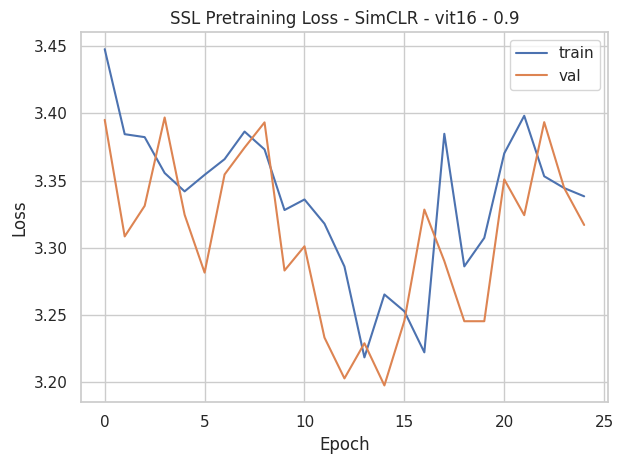

In [ ]:

# 11. Pretraining run

def build_ssl_model():
    _, feat_dim = create_backbone(CFG.BACKBONE)
    if CFG.SSL_METHOD == "SimCLR":
        return SimCLRModel(CFG.BACKBONE, feat_dim)
    if CFG.SSL_METHOD == "BYOL":
        return BYOLModel(CFG.BACKBONE, feat_dim)
    if CFG.SSL_METHOD == "DINO":
        return DINOModel(CFG.BACKBONE, feat_dim)
    raise ValueError("Unsupported SSL method")

all_split_histories = {}
best_ckpt_per_split = {}

for split_ratio in CFG.TRAIN_RATIO_LIST:
    print("" + "="*80)
    print("Pretraining split", split_ratio)
    loaders = build_loaders(split_ratio)
    model = build_ssl_model()
    trainer = SSLTrainer(model, CFG.SSL_METHOD, split_ratio)
    hist_df = trainer.fit(loaders["ssl_train"], loaders["ssl_val"])
    tag = f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}"
    hist_df.to_csv(TAB_DIR / f"{tag}_ssl_history.csv", index=False)
    all_split_histories[split_ratio] = hist_df
    best_ckpt_per_split[split_ratio] = str(trainer.best_path)

    if len(hist_df) > 0:
        plt.figure()
        plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train")
        plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val")
        plt.title(f"SSL Pretraining Loss - {CFG.SSL_METHOD} - {CFG.BACKBONE} - {split_ratio}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"{tag}_pretraining_curve.png", dpi=150, bbox_inches="tight")
        plt.show()

In [ ]:

# 12. Frozen encoder and feature extraction

def get_frozen_encoder_from_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=CFG.DEVICE, weights_only=False)
    _, feat_dim = create_backbone(CFG.BACKBONE)
    if CFG.SSL_METHOD == "SimCLR":
        model = SimCLRModel(CFG.BACKBONE, feat_dim)
        model.load_state_dict(ckpt["model_state_dict"], strict=False)
        encoder = model.encoder
    elif CFG.SSL_METHOD == "BYOL":
        model = BYOLModel(CFG.BACKBONE, feat_dim)
        model.load_state_dict(ckpt["model_state_dict"], strict=False)
        encoder = model.online_encoder
    else:
        model = DINOModel(CFG.BACKBONE, feat_dim)
        model.load_state_dict(ckpt["model_state_dict"], strict=False)
        encoder = model.student_encoder
    encoder = encoder.to(CFG.DEVICE)
    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad = False
    return encoder, feat_dim

def save_frozen_encoder_only(encoder, save_path):
    torch.save({"encoder_state_dict": encoder.state_dict(), "backbone": CFG.BACKBONE, "ssl_method": CFG.SSL_METHOD}, save_path)

@torch.no_grad()
def extract_features(encoder, loader):
    feats, labels, paths = [], [], []
    start = time.time()
    for x, y, p in loader:
        x = x.to(CFG.DEVICE)
        h = encoder(x)
        feats.append(h.detach().cpu().numpy())
        labels.append(y.numpy())
        paths.extend(p)
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0), paths, (time.time() - start)

In [ ]:

# 13. Metrics and plots

def compute_metrics(y_true, y_pred, y_prob=None, class_names=None):
    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    out["precision_macro"] = float(p)
    out["recall_macro"] = float(r)
    out["f1_macro"] = float(f1)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(CFG.NUM_CLASSES)))
    with np.errstate(divide="ignore", invalid="ignore"):
        per_class_acc = np.diag(cm) / cm.sum(axis=1)
        per_class_acc = np.nan_to_num(per_class_acc, nan=0.0)
    out["per_class_accuracy_mean"] = float(per_class_acc.mean())
    out["per_class_accuracy"] = {class_names[i] if class_names else str(i): float(per_class_acc[i]) for i in range(len(per_class_acc))}
    out["confusion_matrix"] = cm.tolist()

    if y_prob is not None:
        try:
            y_bin = label_binarize(y_true, classes=list(range(CFG.NUM_CLASSES)))
            out["roc_auc_ovr_macro"] = float(roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr"))
        except Exception:
            out["roc_auc_ovr_macro"] = None
    else:
        out["roc_auc_ovr_macro"] = None
    return out

def plot_conf_matrix(cm, class_names, save_path, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()

def plot_multiclass_roc(y_true, y_prob, class_names, save_path, title):
    try:
        y_bin = label_binarize(y_true, classes=list(range(CFG.NUM_CLASSES)))
        plt.figure(figsize=(8, 6))
        for i in range(CFG.NUM_CLASSES):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
            plt.plot(fpr, tpr, label=f"{class_names[i]}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.title(title); plt.xlabel("FPR"); plt.ylabel("TPR")
        plt.legend(fontsize=7, ncol=2); plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()
    except Exception as e:
        print("ROC plot skipped:", e)

def maybe_compute_gflops(model, input_size=(1, 3, 224, 224)):
    try:
        from thop import profile
        dummy = torch.randn(*input_size).to(CFG.DEVICE)
        macs, params = profile(model.to(CFG.DEVICE), inputs=(dummy,), verbose=False)
        return float(2 * macs / 1e9), int(params)
    except Exception:
        return None, None

In [ ]:

# 14. Linear probe, shallow heads, fine-tuning

def run_linear_probe(X_train, y_train, X_test, y_test, class_names):
    clf = LogisticRegression(max_iter=2000)
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0
    t1 = time.time()
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)
    test_time = time.time() - t1
    metrics = compute_metrics(y_test, y_pred, y_prob, class_names)
    metrics["train_time_sec"] = float(train_time)
    metrics["test_time_sec"] = float(test_time)
    return metrics, clf

def run_shallow_heads(X_train, y_train, X_test, y_test, class_names):
    models_dict = {
        "MLP": MLPClassifier(hidden_layer_sizes=(256,), max_iter=300, random_state=CFG.RANDOM_SEED),
        "SVM": SVC(probability=True, random_state=CFG.RANDOM_SEED),
        "DecisionTree": DecisionTreeClassifier(random_state=CFG.RANDOM_SEED),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=CFG.RANDOM_SEED, n_jobs=-1),
    }
    results = {}
    for name, clf in models_dict.items():
        t0 = time.time(); clf.fit(X_train, y_train); tr_t = time.time() - t0
        t1 = time.time()
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test) if hasattr(clf, "predict_proba") else None
        te_t = time.time() - t1
        m = compute_metrics(y_test, y_pred, y_prob, class_names)
        m["train_time_sec"] = float(tr_t); m["test_time_sec"] = float(te_t)
        results[name] = m
    return results

class FineTuneClassifier(nn.Module):
    def __init__(self, backbone_name, num_classes):
        super().__init__()
        self.encoder, feat_dim = create_backbone(backbone_name)
        self.classifier = nn.Linear(feat_dim, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))

def train_finetune(model, train_df, val_df, test_df, split_ratio):
    train_loader = DataLoader(LabeledImageDataset(train_df, EVAL_TRANSFORM), batch_size=CFG.BATCH_SIZE_SUP, shuffle=True, num_workers=CFG.NUM_WORKERS)
    val_loader = DataLoader(LabeledImageDataset(val_df, EVAL_TRANSFORM), batch_size=CFG.BATCH_SIZE_SUP, shuffle=False, num_workers=CFG.NUM_WORKERS)
    test_loader = DataLoader(LabeledImageDataset(test_df, EVAL_TRANSFORM), batch_size=CFG.BATCH_SIZE_SUP, shuffle=False, num_workers=CFG.NUM_WORKERS)

    model = model.to(CFG.DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR_FT, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.FT_EPOCHS)

    best_val_acc, best_state = -1.0, None
    hist = []
    for epoch in range(CFG.FT_EPOCHS):
        model.train()
        running_loss = 0.0
        y_true_tr, y_pred_tr = [], []
        for x, y, _ in train_loader:
            x, y = x.to(CFG.DEVICE), y.to(CFG.DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += float(loss.item()) * x.size(0)
            y_true_tr.extend(y.detach().cpu().numpy().tolist())
            y_pred_tr.extend(logits.argmax(1).detach().cpu().numpy().tolist())

        model.eval()
        y_true_va, y_pred_va = [], []
        with torch.no_grad():
            for x, y, _ in val_loader:
                x, y = x.to(CFG.DEVICE), y.to(CFG.DEVICE)
                logits = model(x)
                y_true_va.extend(y.detach().cpu().numpy().tolist())
                y_pred_va.extend(logits.argmax(1).detach().cpu().numpy().tolist())

        tr_acc = accuracy_score(y_true_tr, y_pred_tr)
        va_acc = accuracy_score(y_true_va, y_pred_va)
        scheduler.step()
        hist.append({"epoch": epoch, "train_loss": running_loss / max(len(train_loader.dataset), 1), "train_acc": tr_acc, "val_acc": va_acc})

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())

        if ((epoch + 1) % 10 == 0) or (epoch == 0) or (epoch + 1 == CFG.FT_EPOCHS):
            print(f"FT epoch {epoch+1:03d}/{CFG.FT_EPOCHS} | train_acc={tr_acc:.4f} | val_acc={va_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    y_true_te, y_pred_te, y_prob_te = [], [], []
    with torch.no_grad():
        for x, y, _ in test_loader:
            x = x.to(CFG.DEVICE)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            y_true_te.extend(y.numpy().tolist())
            y_pred_te.extend(logits.argmax(1).cpu().numpy().tolist())
            y_prob_te.extend(probs.cpu().numpy().tolist())

    y_prob_te = np.array(y_prob_te)
    metrics = compute_metrics(np.array(y_true_te), np.array(y_pred_te), y_prob_te, [inv_label_map[i] for i in range(CFG.NUM_CLASSES)])
    metrics["train_history"] = hist

    hist_df = pd.DataFrame(hist)
    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["train_acc"], label="train_acc")
    plt.plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
    plt.title(f"Fine-tuning Accuracy - {CFG.SSL_METHOD} - {CFG.BACKBONE} - {split_ratio}")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_finetune_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    return metrics, model

In [ ]:

# 15. Embeddings, kNN, label-efficiency

def plot_embedding_2d(X_2d, y, class_names, title, save_path):
    plt.figure(figsize=(8, 6))
    for cls in sorted(np.unique(y)):
        idx = y == cls
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=10, alpha=0.7, label=class_names[cls])
    plt.title(title); plt.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()

def run_embedding_analysis(features, labels, split_tag):
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    class_names = [inv_label_map[i] for i in range(CFG.NUM_CLASSES)]
    out = {}

    pca = PCA(n_components=2, random_state=CFG.RANDOM_SEED)
    X_pca = pca.fit_transform(X)
    plot_embedding_2d(X_pca, labels, class_names, f"PCA - {CFG.SSL_METHOD} - {CFG.BACKBONE}", EMB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_{split_tag}_pca.png")
    out["pca_explained_var"] = pca.explained_variance_ratio_.tolist()

    tsne = TSNE(n_components=2, random_state=CFG.RANDOM_SEED, init="pca", learning_rate="auto")
    X_tsne = tsne.fit_transform(X)
    plot_embedding_2d(X_tsne, labels, class_names, f"t-SNE - {CFG.SSL_METHOD} - {CFG.BACKBONE}", EMB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_{split_tag}_tsne.png")

    if UMAP_AVAILABLE:
        reducer = umap.UMAP(n_components=2, random_state=CFG.RANDOM_SEED)
        X_umap = reducer.fit_transform(X)
        plot_embedding_2d(X_umap, labels, class_names, f"UMAP - {CFG.SSL_METHOD} - {CFG.BACKBONE}", EMB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_{split_tag}_umap.png")
    else:
        print("UMAP not available; skipping UMAP.")

    try:
        out["silhouette_score"] = float(silhouette_score(X, labels))
    except Exception:
        out["silhouette_score"] = None
    return out

def run_knn_eval(X_train, y_train, X_test, y_test):
    res = {}
    for k in [1, 5, 20]:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        res[f"knn_acc_k{k}"] = float(accuracy_score(y_test, y_pred))
    return res

def run_label_efficiency(X_train, y_train, X_test, y_test):
    rows = []
    n = len(X_train)
    rng = np.random.RandomState(CFG.RANDOM_SEED)
    for frac in CFG.LABEL_EFF_FRACS:
        subset_n = max(CFG.NUM_CLASSES, int(n * frac))
        idx = rng.choice(np.arange(n), size=subset_n, replace=False)
        clf = LogisticRegression(max_iter=2000)
        clf.fit(X_train[idx], y_train[idx])
        y_pred = clf.predict(X_test)
        rows.append({"label_fraction": frac, "num_samples": subset_n, "linear_probe_acc": float(accuracy_score(y_test, y_pred))})
    eff_df = pd.DataFrame(rows)
    plt.figure()
    plt.plot(eff_df["label_fraction"], eff_df["linear_probe_acc"], marker="o")
    plt.xscale("log")
    plt.title(f"Label Efficiency - {CFG.SSL_METHOD} - {CFG.BACKBONE}")
    plt.xlabel("Label fraction (log scale)"); plt.ylabel("Linear probe accuracy")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_label_efficiency.png", dpi=150, bbox_inches="tight")
    plt.show()
    return eff_df

##########################################################################################
Downstream evaluation for split 0.9
Per-class Accuracy (Linear Probe):


,class_name,accuracy
0,Genus Criconema,0.000000
1,Genus Criconemoides,0.000000
2,Genus Helicotylenchus,0.142857
3,Genus Hemicycliophora,0.000000
4,Genus Hirschmaniella,0.153846
5,Genus Hoplolaimus,0.333333
6,Genus Meloidogyne,0.571429
7,Genus Pratylenchus,0.000000
8,Genus Radopholus,0.000000
9,Genus Trichodorus,0.000000


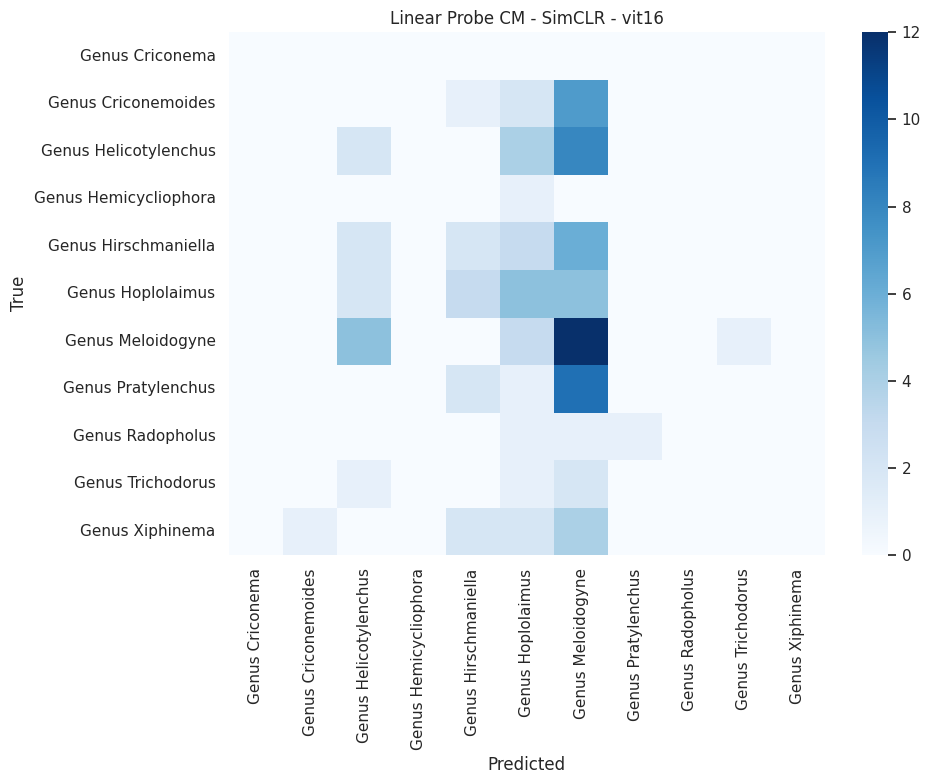

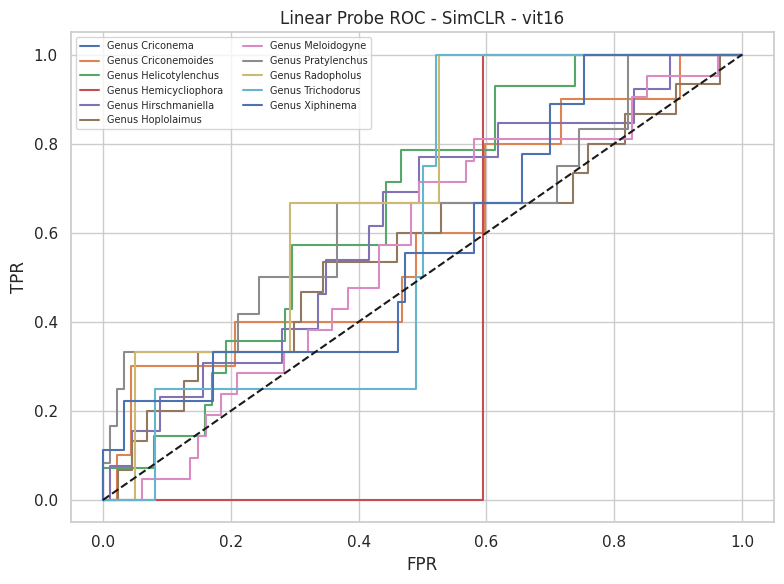

FT epoch 001/20 | train_acc=0.1761 | val_acc=0.1863
FT epoch 010/20 | train_acc=0.5837 | val_acc=0.4902
FT epoch 020/20 | train_acc=0.9667 | val_acc=0.5784


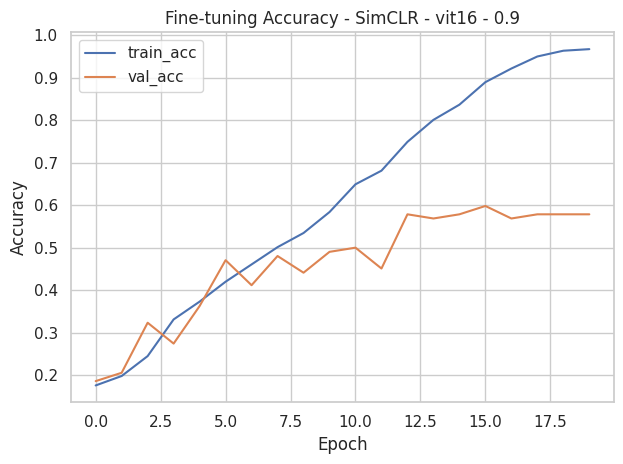

Per-class Accuracy (Fine-Tune):


,class_name,accuracy
0,Genus Criconema,0.000000
1,Genus Criconemoides,0.600000
2,Genus Helicotylenchus,0.571429
3,Genus Hemicycliophora,0.000000
4,Genus Hirschmaniella,0.461538
5,Genus Hoplolaimus,0.400000
6,Genus Meloidogyne,0.857143
7,Genus Pratylenchus,0.500000
8,Genus Radopholus,0.333333
9,Genus Trichodorus,0.500000


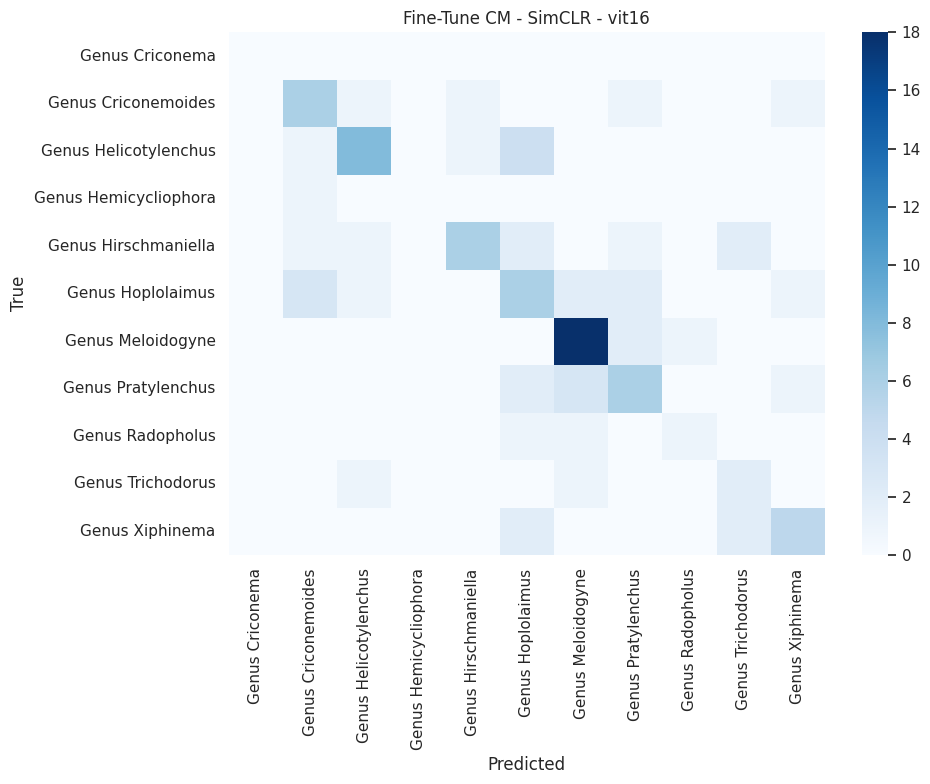

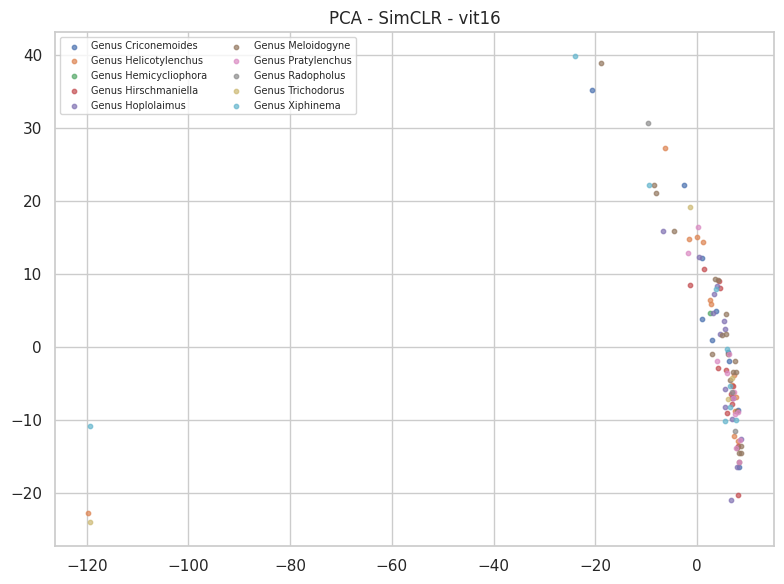

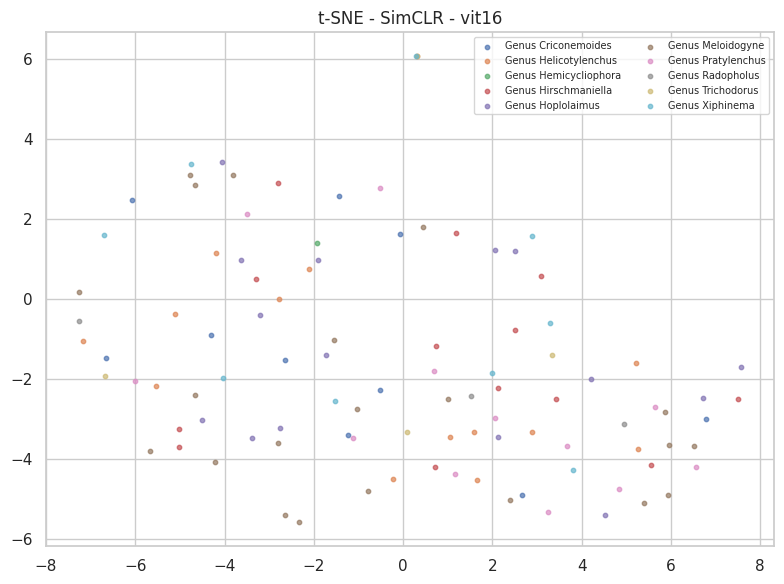

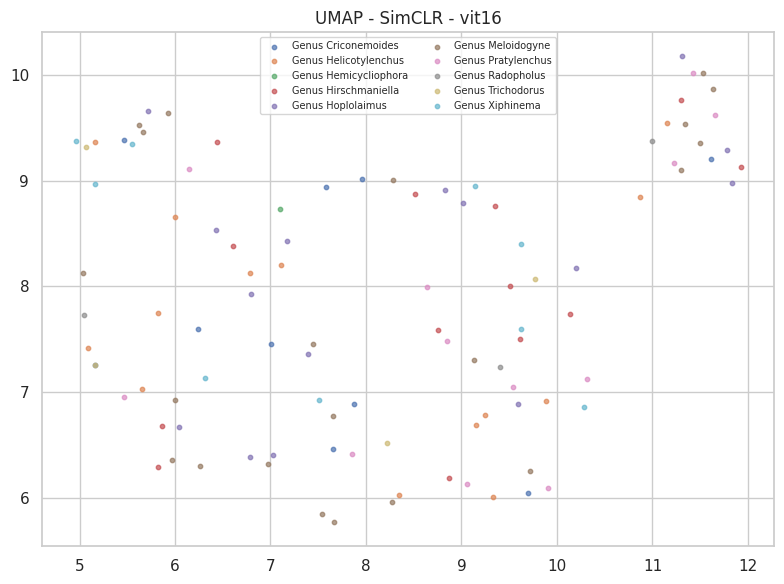

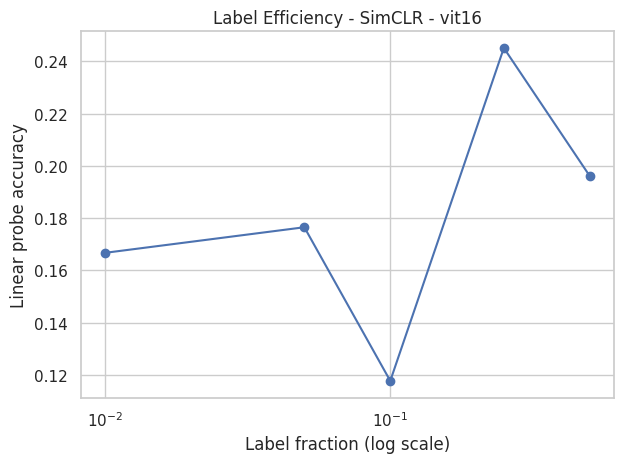

,split_ratio,backbone,ssl_method,encoder_gflops,encoder_params,feature_extract_train_sec,feature_extract_test_sec,linear_probe_acc,linear_probe_f1_macro,linear_probe_auc_ovr_macro,linear_probe_per_class_acc_mean,finetune_acc,finetune_f1_macro,finetune_auc_ovr_macro,finetune_per_class_acc_mean,silhouette_score,knn_acc_k1,knn_acc_k5,knn_acc_k20
0,0.9,vit16,SimCLR,None,None,13.120687,3.304007,0.205882,0.091092,NaN,0.109224,0.568627,0.477811,NaN,0.434454,-0.311565,0.196078,0.176471,0.176471


In [ ]:

# 16. Full downstream evaluation

all_results_rows = []

for split_ratio in CFG.TRAIN_RATIO_LIST:
    print("" + "#"*90)
    print("Downstream evaluation for split", split_ratio)
    split = SPLITS[split_ratio]
    loaders = build_loaders(split_ratio)

    encoder, feat_dim = get_frozen_encoder_from_ckpt(best_ckpt_per_split[split_ratio])
    enc_path = CKPT_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_frozen_encoder.pth"
    save_frozen_encoder_only(encoder, enc_path)

    gflops, nparams = maybe_compute_gflops(encoder, input_size=(1, 3, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE))

    X_train, y_train, _, feat_train_time = extract_features(encoder, loaders["sup_train"])
    X_val, y_val, _, feat_val_time = extract_features(encoder, loaders["sup_val"])
    X_test, y_test, test_paths, feat_test_time = extract_features(encoder, loaders["sup_test"])

    np.save(EMB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_X_train.npy", X_train)
    np.save(EMB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_X_test.npy", X_test)
    np.save(EMB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_y_train.npy", y_train)
    np.save(EMB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_y_test.npy", y_test)

    class_names = [inv_label_map[i] for i in range(CFG.NUM_CLASSES)]

    lp_metrics, lp_clf = run_linear_probe(X_train, y_train, X_test, y_test, class_names)
    print("Per-class Accuracy (Linear Probe):")
    lp_per_class_df = pd.DataFrame.from_dict(lp_metrics["per_class_accuracy"], orient="index", columns=["accuracy"]).reset_index().rename(columns={"index": "class_name"})
    display(lp_per_class_df)

    lp_cm = np.array(lp_metrics["confusion_matrix"])
    plot_conf_matrix(lp_cm, class_names, FIG_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_lp_cm.png", f"Linear Probe CM - {CFG.SSL_METHOD} - {CFG.BACKBONE}")
    plot_multiclass_roc(y_test, lp_clf.predict_proba(X_test), class_names, FIG_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_lp_roc.png", f"Linear Probe ROC - {CFG.SSL_METHOD} - {CFG.BACKBONE}")

    shallow_results = run_shallow_heads(X_train, y_train, X_test, y_test, class_names)

    ft_model = FineTuneClassifier(CFG.BACKBONE, CFG.NUM_CLASSES)
    ft_metrics, ft_model = train_finetune(ft_model, split["train"], split["val"], split["test"], split_ratio)
    print("Per-class Accuracy (Fine-Tune):")
    ft_per_class_df = pd.DataFrame.from_dict(ft_metrics["per_class_accuracy"], orient="index", columns=["accuracy"]).reset_index().rename(columns={"index": "class_name"})
    display(ft_per_class_df)

    ft_cm = np.array(ft_metrics["confusion_matrix"])
    plot_conf_matrix(ft_cm, class_names, FIG_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_ft_cm.png", f"Fine-Tune CM - {CFG.SSL_METHOD} - {CFG.BACKBONE}")

    emb_out = run_embedding_analysis(X_test, y_test, f"split_{int(split_ratio*100)}")
    knn_out = run_knn_eval(X_train, y_train, X_test, y_test)
    label_eff_df = run_label_efficiency(X_train, y_train, X_test, y_test)
    label_eff_df.to_csv(TAB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_label_efficiency.csv", index=False)

    all_results_rows.append({
        "split_ratio": split_ratio,
        "backbone": CFG.BACKBONE,
        "ssl_method": CFG.SSL_METHOD,
        "encoder_gflops": gflops,
        "encoder_params": nparams,
        "feature_extract_train_sec": feat_train_time,
        "feature_extract_test_sec": feat_test_time,
        "linear_probe_acc": lp_metrics["accuracy"],
        "linear_probe_f1_macro": lp_metrics["f1_macro"],
        "linear_probe_auc_ovr_macro": lp_metrics["roc_auc_ovr_macro"],
        "linear_probe_per_class_acc_mean": lp_metrics["per_class_accuracy_mean"],
        "finetune_acc": ft_metrics["accuracy"],
        "finetune_f1_macro": ft_metrics["f1_macro"],
        "finetune_auc_ovr_macro": ft_metrics["roc_auc_ovr_macro"],
        "finetune_per_class_acc_mean": ft_metrics["per_class_accuracy_mean"],
        "silhouette_score": emb_out["silhouette_score"],
        **knn_out,
    })

    full_json = {"linear_probe": lp_metrics, "shallow_heads": shallow_results, "fine_tune": ft_metrics, "embedding": emb_out, "knn": knn_out}
    with open(TAB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_split_{int(split_ratio*100)}_full_results.json", "w", encoding="utf-8") as f:
        json.dump(full_json, f, indent=2)

results_df = pd.DataFrame(all_results_rows)
display(results_df)
results_df.to_csv(TAB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_summary_results.csv", index=False)

,split_ratio,backbone,ssl_method,linear_probe_acc,linear_probe_f1_macro,linear_probe_auc_ovr_macro,finetune_acc,finetune_f1_macro,finetune_auc_ovr_macro,knn_acc_k1,knn_acc_k5,knn_acc_k20,silhouette_score
0,0.9,vit16,SimCLR,0.205882,0.091092,NaN,0.568627,0.477811,NaN,0.196078,0.176471,0.176471,-0.311565


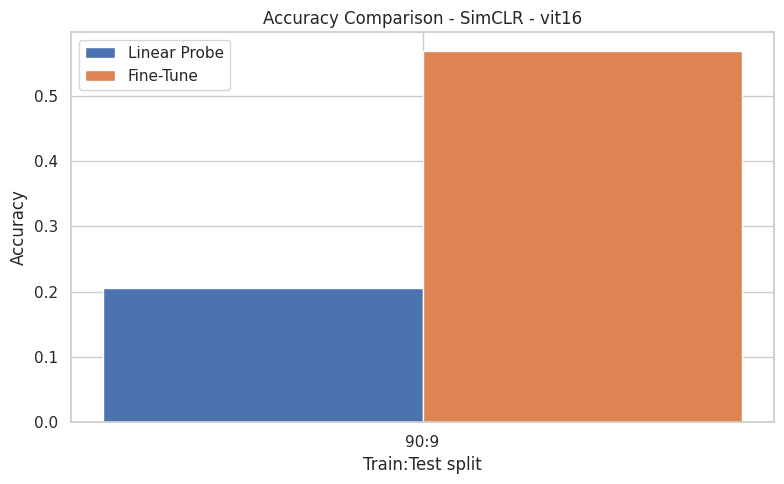

Artifacts saved under: /kaggle/working/simclr_vit16_nematodes


In [ ]:

# 17. Comparison table

if len(results_df) > 0:
    comp_cols = [
        "split_ratio", "backbone", "ssl_method",
        "linear_probe_acc", "linear_probe_f1_macro", "linear_probe_auc_ovr_macro",
        "finetune_acc", "finetune_f1_macro", "finetune_auc_ovr_macro",
        "knn_acc_k1", "knn_acc_k5", "knn_acc_k20", "silhouette_score"
    ]
    comparison_df = results_df[comp_cols].copy()
    display(comparison_df)
    comparison_df.to_csv(TAB_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_brief_comparison_table.csv", index=False)

    plt.figure(figsize=(8, 5))
    x = np.arange(len(comparison_df))
    plt.bar(x - 0.15, comparison_df["linear_probe_acc"], width=0.3, label="Linear Probe")
    plt.bar(x + 0.15, comparison_df["finetune_acc"], width=0.3, label="Fine-Tune")
    plt.xticks(x, [f"{int(s*100)}:{int((1-s)*100)}" for s in comparison_df["split_ratio"]])
    plt.title(f"Accuracy Comparison - {CFG.SSL_METHOD} - {CFG.BACKBONE}")
    plt.xlabel("Train:Test split"); plt.ylabel("Accuracy"); plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{CFG.SSL_METHOD.lower()}_{CFG.BACKBONE}_lp_vs_ft.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Artifacts saved under:", OUT_DIR)